In [ ]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

In [2]:
#import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
#from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import shapely
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date


sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

In [3]:
# path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_plus_area_fix_09042024.csv" # Fires with merge fix + chaining fires fix + fires alseep fix
# fires = fv.prep_fire_files(path, crs = "4326")

#fires = gpd.read_file("~/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb")
fires = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)

fires = fires.to_crs(4326)

In [4]:
# Read in the fire area from the official perimeters

# import os
# import zipfile

# path = '/projects/old_shared/fire_weather_vis/NBAC/'

# os.chdir(path)

# for file in os.listdir('.'):
#     with zipfile.ZipFile(file, 'r') as zip_ref:
#         zip_ref.extractall('.')


prov = fv.ca_prov()
prov = prov[prov.prov_name_en == "Quebec"]

fires = fires.sjoin(prov)

Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5


In [5]:
nbac_only = gpd.read_file(f"{os.path.abspath('contextual_data')}/NBAC/nbac_2023_20240530.shp")

nbac_only = nbac_only[nbac_only.ADMIN_AREA == 'QC']
nbac_only  = nbac_only [(nbac_only.ADJ_HA >= 500) |(nbac_only.POLY_HA >= 500)]

In [6]:
fires = fires.to_crs(nbac_only.crs)
# fires = fires[['fireID', 't', 'geometry','n_pixels',
#        'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
#        'meanFRP', 'lon_centroid',
#        'lat_centroid', 'composit_ids', 'rows_edited']]


def get_max_area(df):
    df["unitless_area"] = df.geometry.area
    df = df[df.unitless_area == df.unitless_area.max()]
    return( df[df.t == df.t.max()])

fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)


/tmp/ipykernel_748/1964064624.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)


In [7]:
fires = fires[['mergeid', 'ftype', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'pixden', 'meanFRP', 't', 't_st', 't_ed',
       'fireID', 'isignition', 't_inactive', 'isactive', 'isdead',
       'mayreactivate', 'geom_counts', 'low_confidence_grouping', 'region',
       'primarykey', 'geometry']]

nbac = nbac_only.sjoin(fires)

In [8]:

nbac = nbac[(nbac.HS_SDATE < "2023-09-15" ) |  (nbac.AG_SDATE < "2023-09-15")]


In [9]:
print(len(nbac.NFIREID.unique()))

print(len(nbac_only.NFIREID.unique())) 
print(len(fires.fireID.unique()))

108
112
173


In [10]:
## Fires not in nbac

feds_only = fires[~fires.fireID.isin(nbac.fireID)]
print(len(feds_only.fireID.unique()))
print(feds_only.groupby("fireID").farea.max().mean())
#feds_only.explore()



## Small, short (1-4 time periods), and possibly tied to static sources and/or false positives. (2 Water bodies,  1 airport).


### 13 in feds, but not in NBAC

14
6.328617393075823


In [11]:
nbac_o = nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID)]
print(len(nbac_o.NFIREID.unique()))
print(nbac_o.groupby("NFIREID").ADJ_HA.max().mean())
#nbac_o.explore() 

## 2 started late enough that it likely wasn't big enough for out analysis. Other 3  all small

4
860.6548700742501


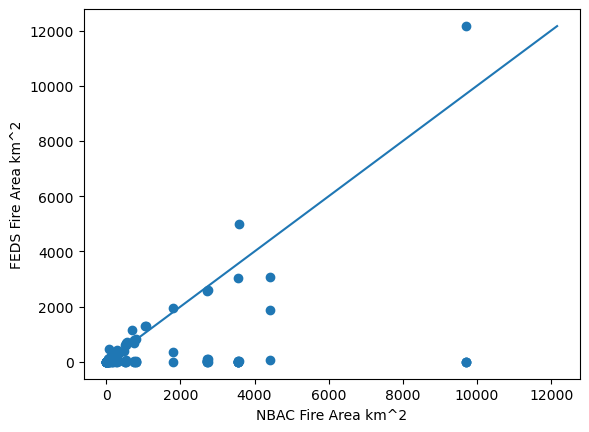

In [12]:
### Look at the fires we agree on. 

import matplotlib.pyplot as plt
seq = range(0, round(nbac.farea.max()), round((nbac.farea.max()/ len(nbac.farea))))

plt.scatter(x = nbac.ADJ_HA/100, y = nbac.farea)
plt.xlabel("NBAC Fire Area km^2")
plt.ylabel("FEDS Fire Area km^2")

plt.plot(seq, seq)

/tmp/ipykernel_748/246568668.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac_plot = nbac.groupby("NFIREID").apply(drop_small_areas).reset_index(drop = True)


IDs where FEDS tracked multiple fires within one NBAC fire 52


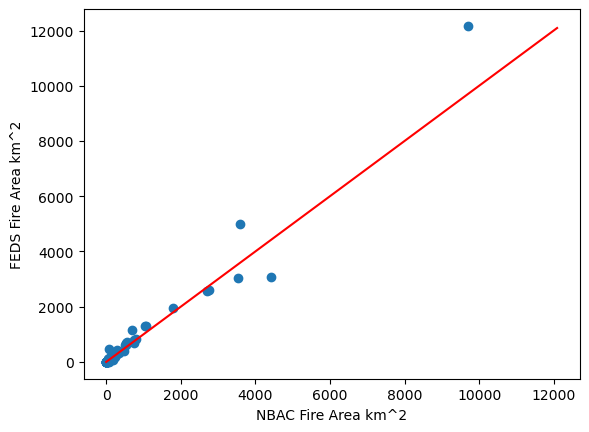

In [13]:
import matplotlib.pyplot as plt



def drop_small_areas(df):
    unique_feds_ids = df.fireID.unique()
    fmax = df.farea.max()
    ## Trying just max to prevent subbing the weird small fires
    fireID = df[df.farea == fmax].fireID.iloc[0]
    df = df[df.fireID == fireID]
    df["max_feds_area"] = df.farea.max()
    return(df)
                           
nbac_plot = nbac.groupby("NFIREID").apply(drop_small_areas).reset_index(drop = True)

print(f'IDs where FEDS tracked multiple fires within one NBAC fire {len(nbac.fireID.unique()) - len(nbac_plot.fireID.unique())}')
seq = range(0, round(nbac_plot.farea.max()), round((nbac_plot.farea.max()/ len(nbac_plot.farea))))

plt.scatter(x = nbac_plot.ADJ_HA/100, y = nbac_plot.max_feds_area)
plt.xlabel("NBAC Fire Area km^2")
plt.ylabel("FEDS Fire Area km^2")

plt.plot(seq, seq, color = "red")
plt.savefig(f'{os.path.abspath("some_figs/")}/NBAC_compare_plot.png', dpi = 900, transparent = True)
plt.show()




In [14]:
### Check the outliers

def get_area_diff(df):
    unique_feds_ids = df.fireID.unique()
    ## Trying just max to prevent subbing the weird small fires
    df["area_source_diff"] = (df.ADJ_HA/100) - df.farea.max()
    return(df)

#nbac["area_source_diff"] = (nbac.ADJ_HA/100) - (nbac.farea)
nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)




plus_10_percent = (nbac.ADJ_HA/100) >= (nbac.farea * 1.1)
minus_10_percent = (nbac.ADJ_HA/100) <= (nbac.farea * 0.9)



bigger_ids = nbac[plus_10_percent].NFIREID.unique() ## 19 larger


nbac = nbac.sort_values(by = "area_source_diff")
bigger_nbac = nbac.groupby("NFIREID").area_source_diff.max().reset_index()
bigger_nbac = bigger_nbac.sort_values(by = "area_source_diff", ascending= False)
bigger_nbac
#bigger_feds = nbac.groupby("NFIREID").area_source_diff.min().reset_index()

/tmp/ipykernel_748/1611368069.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)


,NFIREID,area_source_diff
9,347.0,1333.752437
3,341.0,510.751796
1,339.0,162.522287
10,348.0,142.178722
107,2079.0,111.673837
...,...,...
5,343.0,-233.640157
0,198.0,-387.247312
6,344.0,-472.958780
7,345.0,-1389.806565


In [15]:
### Looking at totals
print(f"Num fires tracked by feds {len(fires.fireID.unique())}")

tot_nbac = np.sum(nbac_only.ADJ_HA)/100


tot_feds = np.sum(fires.farea)

print(f"NBAC found {tot_nbac}km^2 total fire area. FEDS estimated {tot_feds}")

Num fires tracked by feds 173
NBAC found 42561.081494974664km^2 total fire area. FEDS estimated 50536.16004812531


In [16]:
?range

Init signature: range(self, /, *args, **kwargs)
Docstring:     
range(stop) -> range object
range(start, stop[, step]) -> range object

Return an object that produces a sequence of integers from start (inclusive)
to stop (exclusive) by step.  range(i, j) produces i, i+1, i+2, ..., j-1.
start defaults to 0, and stop is omitted!  range(4) produces 0, 1, 2, 3.
These are exactly the valid indices for a list of 4 elements.
When step is given, it specifies the increment (or decrement).
Type:           type
Subclasses:     

In [17]:
import hvplot.pandas
hvplot.extension('bokeh')

In [18]:
#plt.scatter(nbac.ADJ_HA/100, nbac.farea)
#plt.ylabel("NBAC Fire Area km^2")
#plt.xlabel("FEDS Fire Area km^2")

#nbac.hvplot.scatter(x = (nbac.ADJ_HA/100), y = nbac.farea)

In [19]:
df = pd.DataFrame(nbac)


In [20]:
nbac.ADJ_HA/100

24    9693.539897
25    9693.539897
26    9693.539897
27    9693.539897
23    3591.308915
         ...     
16    3541.125248
17    3541.125248
28    4414.291620
29    4414.291620
30    4414.291620
Name: ADJ_HA, Length: 160, dtype: float64

In [21]:
# #hvplot.extension('matplotlib')

# df.hvplot.scatter(x = "ADJ_HA", y = "farea", hover_cols=['fireID', 'NFIREID'])

In [22]:
#nbac[(nbac.NFIREID == 346) & (~nbac.fireID.isna())].explore(column = "fireID")

#nbac[(nbac.NFIREID == 346) & (~nbac.fireID.isna())]



In [23]:
#fires[fires.fireID == 3260].explore()


In [24]:
#fires[fires.fireID == 2665].explore()

In [25]:
# m = fires[fires.fireID == 3261].explore( color = "red")
# nbac[(nbac.NFIREID == 346)].explore(m = m)


In [26]:
nbac[(nbac.NFIREID == 346)].fireID

24     226
25    2665
26    3260
27    3261
Name: fireID, dtype: object

In [27]:
ids = [226, 3261, 2665, 3260]


nbac.loc[(nbac.fireID.isin(ids)), ['NFIREID',
       'HS_SDATE', 'HS_EDATE', 'geometry', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't', 't_st', 't_ed', 'fireID', 'isignition', 't_inactive',
       'isactive', 'isdead', 'mayreactivate', 'geom_counts',
       'low_confidence_grouping']]

,NFIREID,HS_SDATE,HS_EDATE,geometry,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,...,t_st,t_ed,fireID,isignition,t_inactive,isactive,isdead,mayreactivate,geom_counts,low_confidence_grouping


In [28]:
nbac.columns

Index(['YEAR', 'NFIREID', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
       'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
       'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
       'GID', 'geometry', 'index_right', 'mergeid', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't', 't_st', 't_ed', 'fireID', 'isignition', 't_inactive',
       'isactive', 'isdead', 'mayreactivate', 'geom_counts',
       'low_confidence_grouping', 'region', 'primarykey', 'area_source_diff'],
      dtype='object')

In [29]:
# m = fires[fires.fireID == 3261].explore( color = "red")
# m = fires[fires.fireID == 2665].explore(m = m,  color = "yellow")
# m = fires[fires.fireID == 3260].explore( m = m, color = "green")
# fires[fires.fireID == 226].explore(m = m)
